In [6]:
import os

print(os.listdir("./data_madrid"))

['dataset.csv']


In [24]:
import os
import pandas as pd

data_madrid = pd.read_csv(r"data_madrid/dataset-copy.csv")

<class 'pandas.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  str    
 1   zona            11826 non-null  str    
 2   titulo          11826 non-null  str    
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  str    
 8   localizacion    10730 non-null  str    
 9   planta          10601 non-null  str    
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  str    
 12  descripcion     11761 non-null  str    
 13  Enlace          11826 non-null  str    
dtypes: float64(1), int64(4), str(9)
memory usage: 1.3 MB
None


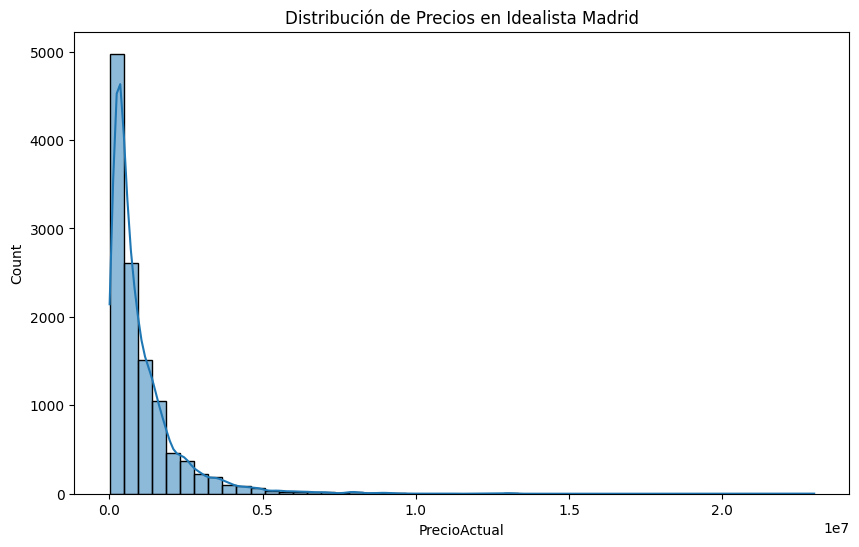

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data_madrid/dataset-copy.csv")

print(df.info())

plt.figure(figsize=(10, 6))
sns.histplot(df['PrecioActual'], bins=50, kde=True)
plt.title('Distribución de Precios en Idealista Madrid')
plt.show()


In [28]:
import sys
print(sys.executable)


/Users/rup/Documents/Factoria F5/ia-regression-project-team-2/.venv/bin/python


In [29]:
import os
from IPython.display import display
print(os.getcwd())
print(os.listdir()) 

for root, dirs, files in os.walk("."):
    if "dataset-copy.csv" in files:
        file_path = os.path.join(root, "dataset.csv")
        print(f"Found it! Loading from: {file_path}")
        df = pd.read_csv(file_path)
        break
else:
    print("File not found in current directory or subdirectories.")

if 'df' in locals():
    pd.options.display.max_columns = None
    display(df.head())

/Users/rup/Documents/Factoria F5/ia-regression-project-team-2
['ia_regression_project_team_2.egg-info', 'data_madrid', 'uv.lock', 'pyproject.toml', 'README.md', '.gitignore', '.env', '.venv', '.python-version', '.git', 'main.py', 'eda-dataset.ipynb']
Found it! Loading from: ./data_madrid/dataset.csv


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [30]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta", "PrecioActual"]
df = df[columns_to_use]

display(df.head())

,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual
0,ciudad-lineal,69,2.0,S,EXTERIOR,5ª,355000
1,carabanchel,91,3.0,N,EXTERIOR,1ª,149000
2,centro,36,1.0,S,NaN,2ª,195000
3,usera,58,1.0,S,INTERIOR,BAJO,195000
4,tetuan,140,3.0,S,EXTERIOR,2ª,715000


In [31]:
print(df.dtypes)

print(df.isnull().sum())

zona                str
metros            int64
habitaciones    float64
ascensor            str
localizacion        str
planta              str
PrecioActual      int64
dtype: object
zona               0
metros             0
habitaciones     366
ascensor         793
localizacion    1096
planta          1225
PrecioActual       0
dtype: int64


In [32]:
display(df.describe())

print(df['zona'].value_counts())
print(df['ascensor'].value_counts())


,metros,habitaciones,PrecioActual
count,11826.000000,11460.000000,1.182600e+04
mean,153.790039,2.847731,1.030501e+06
std,766.217750,1.432402,1.237718e+06
min,11.000000,1.000000,1.200000e+04
25%,68.000000,2.000000,2.890000e+05
50%,103.000000,3.000000,6.200000e+05
75%,160.000000,3.000000,1.329000e+06
max,75000.000000,20.000000,2.300000e+07


zona
barrio-de-salamanca    2018
centro                 1890
chamberi                796
chamartin               706
tetuan                  596
moncloa                 580
carabanchel             567
ciudad-lineal           537
puente-de-vallecas      526
retiro                  508
hortaleza               444
fuencarral              391
arganzuela              386
san-blas                335
latina                  331
villaverde              314
usera                   302
villa-de-vallecas       212
vicalvaro               193
moratalaz                97
barajas                  97
Name: count, dtype: int64
ascensor
S    8419
N    2614
Name: count, dtype: int64


In [ ]:
missing_pct = df.isnull().mean() * 100

columns_over_10pct = missing_pct[missing_pct > 10]
print(columns_over_10pct)

Series([], dtype: float64)


In [45]:
# df['planta'] = df['planta'].fillna(df['planta'].median())

# print(df['planta'].isnull().sum())

In [37]:
print(df['planta'].dtype)
print(df['planta'].unique())


str
<StringArray>
[         '5ª',          '1ª',          '2ª',        'BAJO',          '3ª',
          '6ª',           nan,          '4ª',         '16ª',         '13ª',
          '9ª',          '7ª',         '10ª',          '8ª',         '14ª',
         '11ª',         '12ª', 'ENTREPLANTA',      'SÓTANO',          '-1',
         '15ª',         '17ª',         '20ª',          '-2',         '27ª',
         '22ª',         '21ª',         '18ª']
Length: 28, dtype: str


In [41]:
# Mapping for special floor values
floor_mapping = {
    'BAJO': 0,
    'SÓTANO': -1,
    'ENTREPLANTA': 0.5  # or another value you prefer
}

# Remove 'ª' and convert numeric floors to int
def convert_floor(x):
    if pd.isnull(x):
        return None
    x = str(x).strip()
    if x in floor_mapping:
        return floor_mapping[x]
    try:
        return int(x.replace('ª',''))
    except:
        return None

df['planta_num'] = df['planta'].apply(convert_floor)

# Fill missing values with median
df['planta_num'] = df['planta_num'].fillna(df['planta_num'].median())

# Verify
print(df[['planta','planta_num']].head(15))


   planta  planta_num
0      5ª         5.0
1      1ª         1.0
2      2ª         2.0
3    BAJO         0.0
4      2ª         2.0
5      3ª         3.0
6      6ª         6.0
7      1ª         1.0
8     NaN         2.0
9      3ª         3.0
10     1ª         1.0
11    NaN         2.0
12     2ª         2.0
13     2ª         2.0
14     1ª         1.0


In [39]:
df['planta_num'] = df['planta_num'].fillna(df['planta_num'].median())


In [43]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta_num", "PrecioActual"]
df = df[columns_to_use]

display(df.head())

,zona,metros,habitaciones,ascensor,localizacion,planta_num,PrecioActual
0,ciudad-lineal,69,2.0,S,EXTERIOR,5.0,355000
1,carabanchel,91,3.0,N,EXTERIOR,1.0,149000
2,centro,36,1.0,S,NaN,2.0,195000
3,usera,58,1.0,S,INTERIOR,0.0,195000
4,tetuan,140,3.0,S,EXTERIOR,2.0,715000
